# ModernVBERT on images: digits and hot dogs

> Train sysone's multimodal application, with ModernVBERT as its encoder, on the same 100 MNIST digits (a choice) and 80 food photos (a noul) as the NeoMME tutorial, and look at what it gets right and wrong.

- skip_exec: true
- skip_showdoc: true

sysone's multimodal application answers typed questions about images, here with [ModernVBERT](https://huggingface.co/ModernVBERT/modernvbert) as its encoder, adapted in the [modernvbert](../23_modernvbert.ipynb) notebook. ModernVBERT is a 252M-parameter vision-language encoder: ModernBERT for text, SigLIP2 for images, fused early. This tutorial runs the [NeoMME tutorial](01_neomme_images.ipynb)'s two tasks on it, with the same records, seeds and recipes, and looks at each step: the rows the encoder reads, the training, the answers, and where they go wrong.

- **Digits**, a `choice` question. *Which digit is written in the image?* has ten options. There are 10 MNIST images of each digit to train on, and 10 others of each digit to score.
- **Hot dog, not hot dog**, a `noul`. The statement is *The photo shows a hot dog.* There are 40 photos of each class to train on, and 40 others of each class to score.

On both tasks it compares the same three ways to train: the application's default head on the frozen encoder, a linear head fitted by LBFGS, and LoRA adapters on the text tower. The [comparison](03_neomme_vs_modernvbert.ipynb) notebook puts the two encoders side by side.

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). It downloads ModernVBERT (`ModernVBERT/modernvbert`, 1.2 GB of float32 weights, MIT) and the two datasets from the Hugging Face Hub. After that, the whole run takes about 23 minutes on an M3 Pro (MPS, fp32), and the outputs below come from a run on 2026-09-27. It needs the `multimodal` and `plots` extras (`pip install "sysone[multimodal,plots]"`), and it saves its images in `modernvbert-images/`, next to the notebook.
:::

```{mermaid}
flowchart LR
    R["a record: an image path,<br/>a question, the gold answer"] --> T["the Image transform:<br/>load, resize to 512 px"]
    T --> I["Idefics3's processor:<br/>one 512-px tile"]
    I --> W["a row: Laya's layout, the image<br/>as 64 <image> tokens"]
    W --> E["ModernVBERT,<br/>frozen or with LoRA"]
    E --> A["a vector at<br/>each anchor"]
    A --> S["the head: standardise,<br/>score each anchor"]
    S --> J["÷ temperature, softmax:<br/>the answer"]
```

### Two towers, fused early

ModernVBERT has two parts. SigLIP2, a 12-layer vision transformer trained on images and their captions, turns each 512-pixel tile of an image into 1,024 patch vectors. ModernBERT, a 22-layer text encoder, reads the row. *Early fusion* means that the image's vectors enter ModernBERT as tokens of the same row, next to the question and the options, so each of its 22 layers can mix words and image. CLIP and models like it fuse late instead: the text and the image each end up as one vector, and only the two vectors are compared. A head that reads the options' anchors needs early fusion, since that is how the image reaches the anchors.

In [ ]:
import gc, io, json, logging, random, shutil, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
from matplotlib.patches import Rectangle
from matplotlib_inline.backend_inline import set_matplotlib_formats
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, display
import datasets, huggingface_hub, transformers
from huggingface_hub import snapshot_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.core import collate
from sysone.data import TypedDecisions
from sysone.losses import answer_metrics
from sysone.multimodal import decision_learner

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.logging.set_verbosity_error(); huggingface_hub.utils.logging.set_verbosity_error()
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110          # plain PNG plots, a third the size of retina ones
data_dir = Path("modernvbert-images")          # the images this notebook saves
ENC = "ModernVBERT/modernvbert"
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


The helpers are the NeoMME tutorial's. `quiet` removes the Trainer's per-step log lines (`learn.recorder` keeps the numbers), `release` hands back the memory of deleted learners, and `metrics` picks the numbers worth a look out of `validate`. Each learner loads its own copy of ModernVBERT, so the notebook deletes a learner once it's done with it.

In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs (`learn.recorder` still has them)"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted learners"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def metrics(learn):
    "The held-out metrics worth a look, rounded"
    return {k: round(v, 3) for k, v in learn.validate().items() if k in ("accuracy", "soft_accuracy", "brier", "ece", "n")}

The plotting code is folded, since none of it is sysone's API. It adds one function to the NeoMME tutorial's: `show_tiles` draws the tiles an image becomes, with a grid of the 64-pixel squares that each turn into one image token.

In [ ]:
#| code-fold: true
#| code-summary: plotting helpers
BLUE, LIGHT, TRACK, CARD, INK, GRAY = "#3b3ff5", "#9a9df7", "#d4d4d4", "#f2f2f2", "#111111", "#6b6b6b"

def show_figure(fig, fmt="png", dpi=90):
    "Display a figure as PNG, or as JPEG for photos, and close it"
    buf = io.BytesIO()
    fig.savefig(buf, format=fmt, dpi=dpi, **({"pil_kwargs": {"quality": 85}} if fmt == "jpeg" else {})); plt.close(fig)
    display(DisplayImage(buf.getvalue(), format=fmt))

def _line(ax, x, y, parts, size):
    "Pieces of text in their own weight and colour on one line, its top left corner at (x, y) in axes fraction"
    box = HPacker(children=[TextArea(s, textprops=dict(size=size, **kw)) for s, kw in parts], sep=size * 0.35, pad=0, align="baseline")
    ax.add_artist(AnchoredOffsetbox("upper left", child=box, bbox_to_anchor=(x, y), bbox_transform=ax.transAxes,
                                    frameon=False, pad=0, borderpad=0))

def square(im):
    "The centre square of a PIL image"
    w, h = im.size; s = min(w, h)
    return im.crop(((w - s) // 2, (h - s) // 2, (w - s) // 2 + s, (h - s) // 2 + s))

def _card(sf, image, gold, probs, top):
    "One card: the image, the gold label's probability and rank, and the most likely labels as bars"
    sf.set_facecolor(CARD)
    order = sorted(probs, key=probs.get, reverse=True)
    head = sf.add_axes([0.03, 0.84, 0.94, 0.12]); head.axis("off")
    _line(head, 0, 1, [(f"{gold} ({probs[gold]:.1%})", dict(weight="bold", color=INK)),
                       (f"Ranked {order.index(gold) + 1} out of {len(order)} labels", dict(color=GRAY))], 13)
    im = square(PILImage.open(image))
    ax = sf.add_axes([0.03, 0.06, 0.34, 0.74]); ax.axis("off")
    ax.imshow(im, cmap="gray" if im.mode == "L" else None, interpolation="nearest" if im.size[0] < 64 else "antialiased")
    bars = sf.add_axes([0.41, 0.06, 0.56, 0.74]); bars.axis("off"); bars.set_xlim(0, 1); bars.set_ylim(0, 1)
    for i, lab in enumerate(order[:top]):
        y, ok = 1 - i / 5, lab == gold
        bars.add_patch(Rectangle((0, y - 0.08), 1, 0.06, color=TRACK, lw=0))
        bars.add_patch(Rectangle((0, y - 0.08), max(probs[lab], 0.004), 0.06, color=BLUE if i == 0 else LIGHT, lw=0))
        _line(bars, 0, y - 0.11, [("✓" if ok else "✕", dict(color=INK if ok else GRAY)),
                                  (lab, dict(weight="bold", color=INK if ok else GRAY))], 11.5)

def show_cards(cards, ncols=2, top=5, fmt="png"):
    "Prediction cards in a grid, each a dict of an image path, the gold label and every label's probability"
    nrows = -(-len(cards) // ncols)
    fig = plt.figure(figsize=(6.2 * ncols, 2.8 * nrows))
    sfs = np.atleast_1d(fig.subfigures(nrows, ncols, wspace=0.02, hspace=0.04)).ravel()
    for sf, c in zip(sfs, cards): _card(sf, c["image"], c["gold"], c["probs"], top)
    for sf in sfs[len(cards):]: sf.set_facecolor("white")
    show_figure(fig, fmt)

def plot_history(learn, title, chance):
    "The training loss at every logged step, and the held-out loss and accuracy after every epoch"
    ms, tr = learn.recorder.metrics, learn.recorder.losses
    ep = [m["epoch"] for m in ms]; x = np.linspace(ep[-1] / len(tr), ep[-1], len(tr))
    fig, (a, b) = plt.subplots(1, 2, figsize=(10, 2.8))
    a.plot(x, tr, color="gray", lw=1, label="training rows"); a.plot(ep, [m["loss"] for m in ms], color="C0", lw=1.5, label="held-out rows")
    a.set(xlabel="epoch", ylabel="loss (soft CE)"); a.legend(frameon=False)
    b.plot(ep, [m["accuracy"] for m in ms], color="C0", lw=1.5); b.axhline(chance, ls="--", color="gray", lw=1)
    b.text(ep[-1], chance + 0.02, "chance", ha="right", va="bottom", color="gray", fontsize=9)
    b.set(xlabel="epoch", ylabel="held-out accuracy", ylim=(0, 1)); fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def plot_confusion(panels, labels):
    "A confusion matrix per model: a row per gold label, a column per answer"
    fig, axs = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.4), squeeze=False)
    for ax, (name, (gold, pred)) in zip(axs[0], panels.items()):
        M = np.zeros((len(labels), len(labels)), int)
        for g, p in zip(gold, pred): M[labels.index(g), labels.index(p)] += 1
        top = M.sum() / len(labels)
        ax.imshow(M, cmap="Blues", vmin=0, vmax=top)
        for (r, c), v in np.ndenumerate(M):
            if v: ax.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > top / 2 else INK)
        ax.set(xticks=range(len(labels)), yticks=range(len(labels)), xlabel="answer", ylabel="gold")
        ax.set_xticklabels(labels, fontsize=8); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f"{name}: accuracy {np.trace(M) / M.sum():.2f}", fontsize=10)
    plt.tight_layout(); plt.show()

def show_grid(img, h, w, p=32, title="", fmt="png"):
    "An image with its grid of p-pixel patches drawn over it"
    fig, ax = plt.subplots(figsize=(0.45 * w + 0.4, 0.45 * h + 0.6))
    ax.imshow(img, interpolation="nearest")
    for r in range(1, h): ax.axhline(r * p - 0.5, color="C1", lw=0.8)
    for c in range(1, w): ax.axvline(c * p - 0.5, color="C1", lw=0.8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=10)
    show_figure(fig, fmt, dpi=110)

def row_tiles(learn, split="train", i=0):
    "A row's tiles as the encoder receives them, in [0, 1], and the row's length in tokens"
    row, ip = learn.data.lazy_rows(split)[i], learn.data.builder.processor.image_processor
    std, mean = torch.tensor(ip.image_std)[:, None, None], torch.tensor(ip.image_mean)[:, None, None]
    return (row["pixel_values"] * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy(), len(row["input_ids"])

def show_tiles(tiles, title="", cell=64, fmt="png"):
    "Tiles side by side, each with a grid of `cell`-pixel squares: 4 × 4 SigLIP patches, pixel-shuffled into one image token"
    fig, axs = plt.subplots(1, len(tiles), figsize=(max(4.6, 2.8 * len(tiles)), 4.6), squeeze=False)
    for ax, t in zip(axs[0], tiles):
        ax.imshow(t, interpolation="antialiased")
        for k in range(1, t.shape[0] // cell): ax.axhline(k * cell - 0.5, color="C1", lw=0.9); ax.axvline(k * cell - 0.5, color="C1", lw=0.9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=9); fig.tight_layout(); show_figure(fig, fmt, dpi=100)

## Digits: a choice question

The records are the NeoMME tutorial's: `mnist_records` goes through each MNIST split in a seeded random order and keeps the first 10 images of each digit, so every run, and every notebook, draws the same 100 images to train on and 100 to score.

In [ ]:
def mnist_records(per_class=10, seed=0, dest=data_dir / "mnist"):
    "Choice records over MNIST: `per_class` images of each digit from its train split, and as many from its test split"
    rng, ds = random.Random(seed), datasets.load_dataset("ylecun/mnist")
    q = {"digit": {"type": "choice", "instructions": "Which digit is written in the image?", "criteria": [str(d) for d in range(10)]}}
    out = {}
    for split in ("train", "test"):
        labels, by = ds[split]["label"], {d: [] for d in range(10)}
        for i in rng.sample(range(len(labels)), len(labels)):
            if len(by[labels[i]]) < per_class: by[labels[i]].append(i)
            if all(len(v) == per_class for v in by.values()): break
        (dest / split).mkdir(parents=True, exist_ok=True); out[split] = []
        for d, idx in by.items():
            for i in idx:
                p = dest / split / f"{i}.png"
                if not p.exists(): ds[split][i]["image"].save(p)     # saved once: the feature cache keys on each file's size and time
                out[split].append({"id": f"mnist-{split}-{i}", "state": {"text": "", "image": str(p)}, "questions": q,
                                   "gold": {"digit": {"label": str(d)}}})
        rng.shuffle(out[split])
    return out["train"], out["test"]

train, test = mnist_records()
print(len(train), "cases to train on,", len(test), "to score")
print(json.dumps(train[0], indent=1))

100 cases to train on, 100 to score
{
 "id": "mnist-train-27562",
 "state": {
  "text": "",
  "image": "modernvbert-images/mnist/train/27562.png"
 },
 "questions": {
  "digit": {
   "type": "choice",
   "instructions": "Which digit is written in the image?",
   "criteria": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
   ]
  }
 },
 "gold": {
  "digit": {
   "label": "8"
  }
 }
}


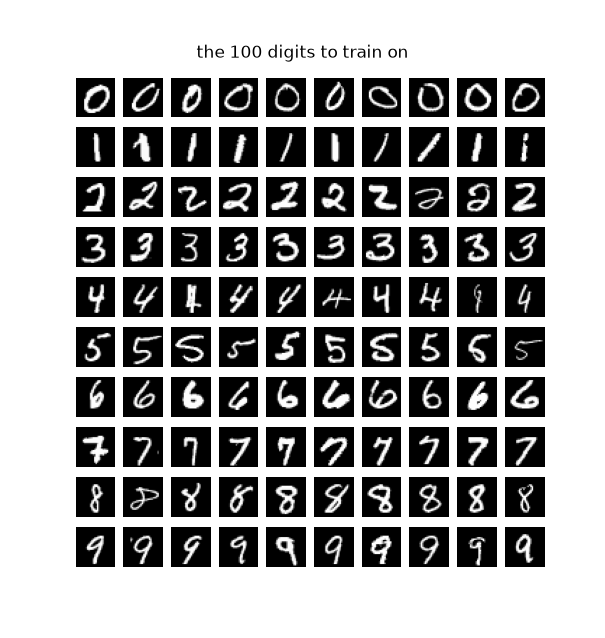

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(10, 10, figsize=(5.5, 5.8))
for d in range(10):
    for j, r in enumerate(r for r in train if r["gold"]["digit"]["label"] == str(d)):
        axs[d, j].imshow(PILImage.open(r["state"]["image"]), cmap="gray"); axs[d, j].axis("off")
fig.suptitle("the 100 digits to train on", y=0.93, fontsize=11); show_figure(fig, dpi=110)

### A learner, and what it reads

`decision_learner` binds the records to ModernVBERT's tokenizer and processor, adds the `Image` transform (load, resize to `image_side`), sets the processor to tile at `image_side`, loads the encoder and builds the head. At `image_side=512`, the default, a digit is one tile. With `train="head"` the encoder stays frozen and the anchors are cached. `TypedDecisions.from_records` holds out a fifth of the training cases (`calib=0.2`) to fit the temperatures, so the heads learn from 80 digits. And `image_side` matters more than it looks: left to the checkpoint's defaults, the processor would enlarge a 28-pixel digit to 2,048 pixels, 17 tiles and an image block of 1,127 tokens, instead of one tile and 67.

In [ ]:
data = TypedDecisions.from_records(train, valid=test, calib=0.2)
torch.manual_seed(0)
learn = quiet(decision_learner(data, ENC, train="head", image_side=512))
print(learn)          # printed, not displayed: IPython's output history would keep the learner, and its encoder, alive

Learner(ModernVBERT/modernvbert · regime head · head 0 layers/laya · cache masks · loss soft_ce · 595,201 of 252,597,505 params train)


`show_batch` prints a training row as the encoder reads it, with runs of image tokens counted:

In [ ]:
learn.show_batch(1)

[CLS] choice question: Which digit is written in the image? [SEP] [MASK] 0 [MASK] 1 [MASK] 2 [MASK] 3 [MASK] 4 [MASK] 5 [MASK] 6 [MASK] 7 [MASK] 8 [MASK] 9 [SEP] <fake_token_around_image> <global-img> <image>×64 <fake_token_around_image> [SEP]
markers [13, 15, 17, 19, 21, 23, 25, 27, 29, 31] · qtype choice · 102 tokens



The row is Laya's: `[CLS]`, the question, `[SEP]`, and the ten options, each after a `[MASK]`, the anchor where the head reads that option's vector. Laya is the decision model whose recipe sysone follows. ModernBERT was trained to fill in `[MASK]`, so its output there sums up what belongs in that slot, given the question, the image and the option right after it. The head scores every anchor with the same weights, and a softmax across the options gives the probabilities.

Then comes the image block, `<fake_token_around_image>`, `<global-img>`, 64 `<image>` tokens and `<fake_token_around_image>`, and the row ends with `[SEP]`. The processor has enlarged the 28-pixel digit to a single 512-pixel tile. SigLIP2 cuts the tile into 32 × 32 patches of 16 pixels, and the pixel shuffle folds each 4 × 4 block of patches into one vector, one image token per 64-pixel square:

1 tile of 512 × 512 pixels · a row of 102 tokens


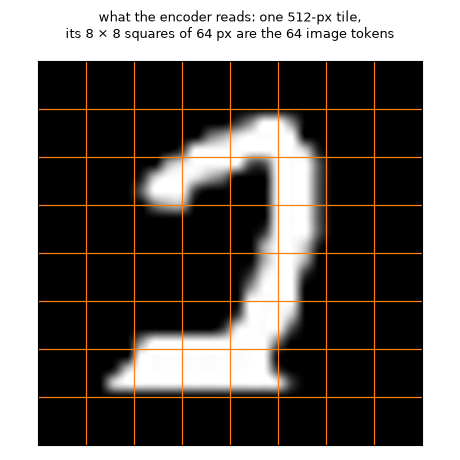

In [ ]:
tiles, n = row_tiles(learn)
print(f"{len(tiles)} tile of {tiles.shape[1]} × {tiles.shape[2]} pixels · a row of {n} tokens")
show_tiles(tiles, title="what the encoder reads: one 512-px tile,\nits 8 × 8 squares of 64 px are the 64 image tokens")

The pixel shuffle is a reshape, not a learned layer. It takes each 4 × 4 block of neighbouring patch vectors and lays the 16 end to end, one vector 16 times as wide. Nothing is thrown away: a tile's numbers now fit in 64 positions instead of 1,024, like 16 stamps stacked into one pile. One linear layer, 12,288 numbers in and 768 out, then turns each pile into a token ModernBERT can read. Here is the connector's own `pixel_shuffle` on a toy tile of 8 × 8 patches, each patch a single number, its position:

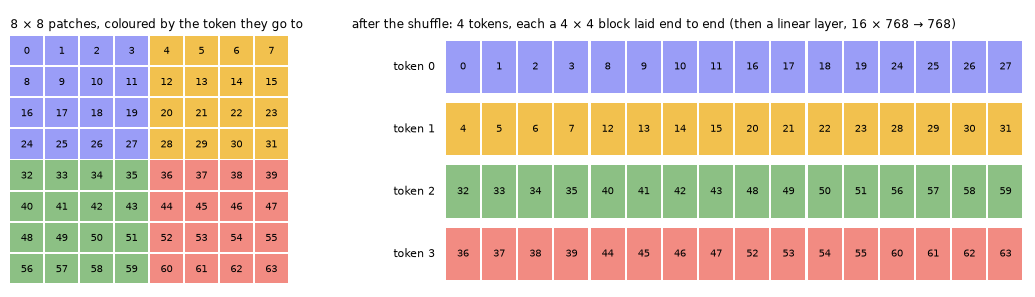

In [ ]:
#| code-fold: true
#| code-summary: the pixel shuffle, on a toy tile
from transformers.models.modernvbert.modeling_modernvbert import ModernVBertConnector
patches = torch.arange(64.).reshape(1, 64, 1)                                   # 8 × 8 patches, each a 1-number vector: its index
tokens = ModernVBertConnector.pixel_shuffle(None, patches, 4)[0].int().numpy()   # the checkpoint's factor, 4: (4 tokens, 16 numbers)
owner = np.empty(64, int); owner[tokens.ravel()] = np.repeat(np.arange(len(tokens)), tokens.shape[1])
colors = ["#9a9df7", "#f2c14e", "#8cc084", "#f28b82"]
fig = plt.figure(figsize=(11.5, 3.3))
ax = fig.add_axes([0.01, 0.04, 0.27, 0.84]); ax.set_xlim(0, 8); ax.set_ylim(8, 0); ax.axis("off")
for i in range(64):
    r, c = divmod(i, 8)
    ax.add_patch(Rectangle((c, r), 0.94, 0.94, color=colors[owner[i]], lw=0)); ax.text(c + 0.47, r + 0.5, i, ha="center", va="center", fontsize=8)
ax.set_title("8 × 8 patches, coloured by the token they go to", fontsize=9.5, loc="left")
bx = fig.add_axes([0.34, 0.04, 0.65, 0.84]); bx.set_xlim(-2.6, 16); bx.set_ylim(len(tokens), 0); bx.axis("off")
for t, row in enumerate(tokens):
    bx.text(-0.3, t + 0.5, f"token {t}", ha="right", va="center", fontsize=9)
    for j, i in enumerate(row):
        bx.add_patch(Rectangle((j, t + 0.08), 0.94, 0.84, color=colors[t], lw=0)); bx.text(j + 0.47, t + 0.5, i, ha="center", va="center", fontsize=8)
bx.set_title("after the shuffle: 4 tokens, each a 4 × 4 block laid end to end (then a linear layer, 16 × 768 → 768)", fontsize=9.5, loc="left")
show_figure(fig)

Each token is one 4 × 4 block: token 0 holds patches 0 to 3, 8 to 11, 16 to 19 and 24 to 27, the top-left corner. In the real tile each number stands for a 768-wide vector from SigLIP2, so a token is 16 × 768 = 12,288 numbers before the linear layer. What the shuffle gives up is resolution for the attention, not information: ModernBERT sees 64 positions per tile, and each carries all that SigLIP2 said about its 64-pixel square.

### Training the head

The encoder runs once over every row, and the anchor vectors are stored:

In [ ]:
t0 = time.time()
for split in ("train", "calib", "valid"): learn.dataset(split)
print(f"the anchors of {sum(len(learn.dataset(s)) for s in ('train', 'calib', 'valid'))} rows, cached in {time.time() - t0:.0f} s")

the anchors of 200 rows, cached in 18 s


The default head is Laya's scorer on the anchors. ModernVBERT's width is 768, so that's a 768 × 768 layer and a layer down to one score, about 600,000 weights for 80 examples. The recipe is the NeoMME tutorial's: 30 epochs at 10⁻³, warmup then cosine decay, and a temperature fitted on the calib split after the fit. `lr_find` first, for what it says:

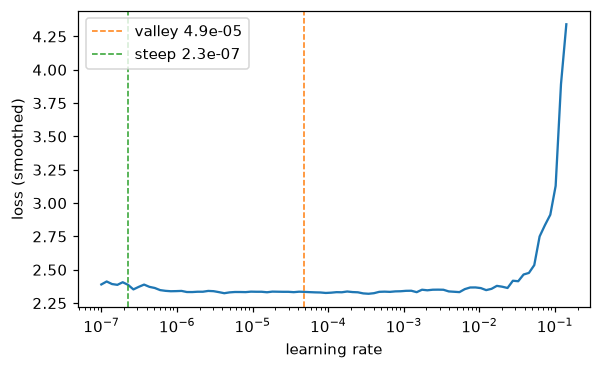

SuggestedLRs(valley=4.86e-05, steep=2.26e-07)

In [ ]:
sugg = learn.lr_find()
learn.plot_lr_find(sugg); plt.show()
sugg

trained in 7.4 s; temperatures {'choice': 1.2176, 'choice:6-10': 1.2176}


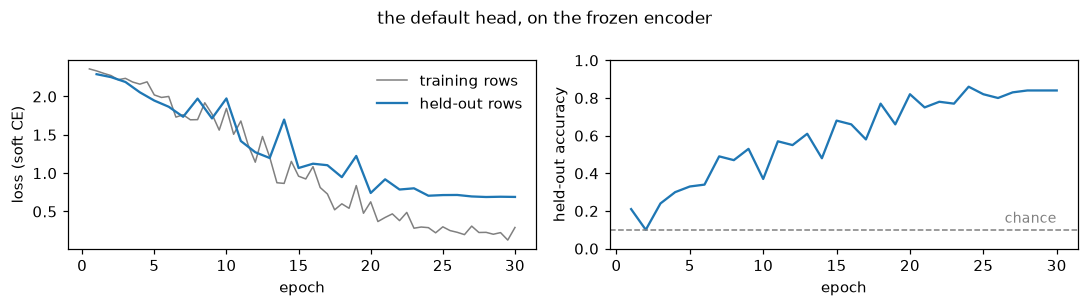

{'accuracy': 0.84,
 'soft_accuracy': 0.676,
 'brier': 0.262,
 'ece': 0.15,
 'n': 100}

In [ ]:
t0 = time.time()
learn.fit_one_cycle(30, lr=1e-3)
print(f"trained in {time.time() - t0:.1f} s; temperatures {learn.temperatures}")
plot_history(learn, "the default head, on the frozen encoder", chance=0.1)
metrics(learn)

The default head reaches 0.84 on the 100 held-out digits, where NeoMME's reached 0.31 with the same recipe. Its held-out loss falls with the training loss for 20 epochs and then levels off near 0.7, and its accuracy climbs through the whole run. The range test's valley (5 × 10⁻⁵) is as cautious as it was for NeoMME: 10⁻³ trains well. The temperature fitted on the calib split is 1.22, so the head's probabilities needed only a little softening.

::: {.callout-tip title="Jargon: calibration"}
A model is **calibrated** when its probabilities mean what they say: of the answers it gives at 70%, about 70% are right. A **temperature** $T$ is one number that divides the head's scores before the softmax. $T > 1$ softens overconfident probabilities and $T < 1$ sharpens timid ones, and the top answer never changes, so a temperature moves the Brier score and the ECE but not the accuracy. sysone fits one on the calib split for each question type and option count (`choice:6-10`), between 0.5 and 5. In `validate`'s numbers, `soft_accuracy` is the mean probability given to the right answer, `brier` the squared distance between the probabilities and the one-hot truth, summed over the options (a uniform guess scores 0.9 on ten options and 0.5 on a noul), and `ece` the gap between confidence and accuracy, averaged over bins of answers with similar confidence.
:::

### The answers

In [ ]:
q = test[0]["questions"]
answers = {"default head": learn.decider().predict_batch([r["state"] for r in test], q)}
print(json.dumps(answers["default head"][0], indent=1))
m = answer_metrics([(q, a, r["gold"]) for a, r in zip(answers["default head"], test)])
print("the answers' metrics:", {k: round(m[k], 3) for k in ("accuracy", "soft_accuracy", "brier", "ece")})

{
 "digit": {
  "type": "choice",
  "choice": "5",
  "probabilities": {
   "0": 0.0002,
   "1": 0.0,
   "2": 0.036,
   "3": 0.0065,
   "4": 0.1115,
   "5": 0.8105,
   "6": 0.0334,
   "7": 0.0004,
   "8": 0.001,
   "9": 0.0005
  },
  "confidence": 0.6975,
  "answer_confidence": 0.8105
 }
}
the answers' metrics: {'accuracy': 0.84, 'soft_accuracy': 0.676, 'brier': 0.262, 'ece': 0.15}


The first test image of each digit, with the probability the head gave the right digit and its five most likely digits:

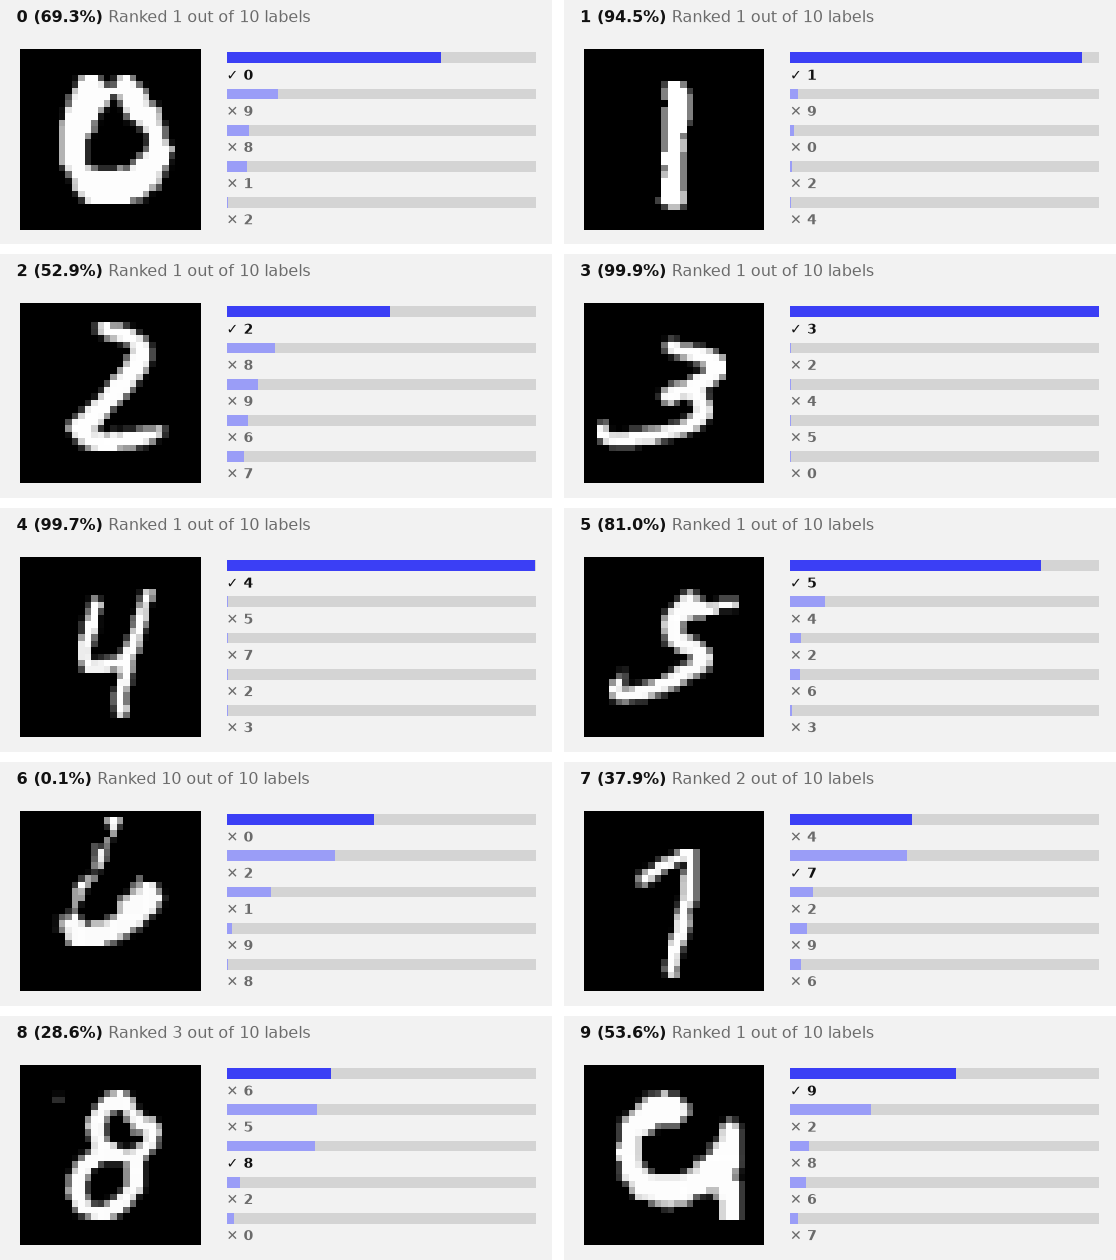

In [ ]:
def digit_cards(answers, recs):
    "A card per record: its image, its gold digit and every digit's probability"
    return [{"image": r["state"]["image"], "gold": r["gold"]["digit"]["label"], "probs": a["digit"]["probabilities"]}
            for a, r in zip(answers, recs)]

firsts = [next(i for i, r in enumerate(test) if r["gold"]["digit"]["label"] == str(d)) for d in range(10)]
show_cards(digit_cards([answers["default head"][i] for i in firsts], [test[i] for i in firsts]))

Seven of the ten are right, four of them above 80%. The misses are the thin, open 6, to which the head gives 0.1% while it answers 0, the 7 read as a 4 with the 7 second, and the 8, third behind a 6 and a 5.

### Does ModernVBERT need standardising?

NeoMME's anchor vectors all had one channel holding almost their whole length, and its heads barely learned until they standardised their input. The same look at ModernVBERT's 80 × 10 training anchors:

In [ ]:
A = np.concatenate([np.asarray(a, dtype=np.float32) for a in learn.dataset("train")["anchors"]])
norm, mu, sd = np.linalg.norm(A, axis=1), A.mean(0), A.std(0)
c = int(np.abs(mu).argmax())
print(f"{A.shape[0]} vectors of width {A.shape[1]}, norm {norm.mean():.2f} ± {norm.std():.3f}")
print(f"channel {c}: mean {mu[c]:.2f}, sd {sd[c]:.3f}, {np.mean(np.abs(A[:, c]) / norm):.1%} of every vector's norm")
print(f"the other {A.shape[1] - 1} channels: |mean| at most {np.sort(np.abs(mu))[-2]:.2f}, sd at most {np.delete(sd, c).max():.3f}")

800 vectors of width 768, norm 48.99 ± 0.272
channel 256: mean -28.21, sd 0.950, 57.6% of every vector's norm
the other 767 channels: |mean| at most 5.97, sd at most 1.203


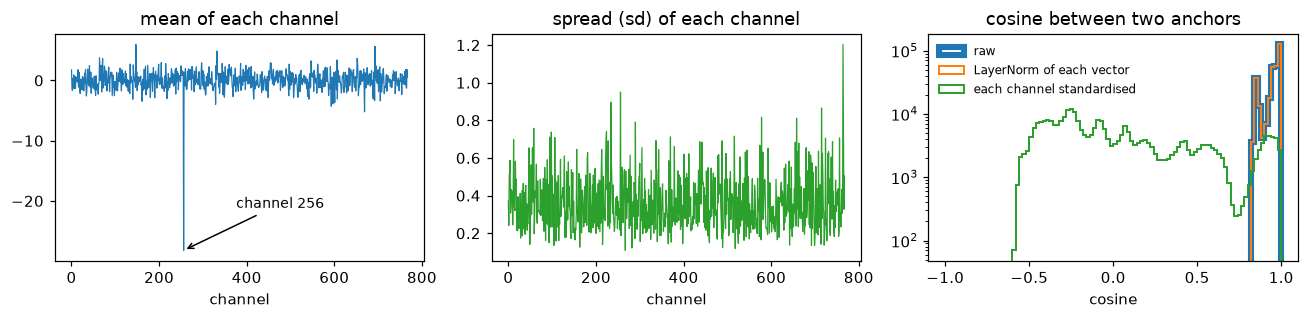

In [ ]:
#| code-fold: true
#| code-summary: figure code
def cosines(X):
    X = X / np.linalg.norm(X, axis=1, keepdims=True); C = X @ X.T
    return C[np.triu_indices(len(X), 1)]
layer_norm = lambda X: (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(mu, lw=0.8); axs[0].set(title="mean of each channel", xlabel="channel")
axs[0].annotate(f"channel {c}", (c, mu[c]), (c + 120, mu[c] * 0.75), arrowprops=dict(arrowstyle="->"), fontsize=9)
axs[1].plot(sd, lw=0.8, color="C2"); axs[1].set(title="spread (sd) of each channel", xlabel="channel")
for X, name, lw in ((A, "raw", 4), (layer_norm(A), "LayerNorm of each vector", 1.3), ((A - mu) / sd, "each channel standardised", 1.3)):
    axs[2].hist(cosines(X), bins=100, range=(-1, 1), histtype="step", lw=lw, label=name)
axs[2].set(title="cosine between two anchors", yscale="log", xlabel="cosine"); axs[2].legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

ModernVBERT has a dominant channel too, a milder one than NeoMME's. Channel 256 sits at −28 in every anchor, with a spread under 1, and it carries 58% of each vector's length, where NeoMME's channel 139 carried 97%. Every vector is about 49 long. Any two raw anchors have a cosine above 0.8, and a LayerNorm of each vector leaves them there. Standardising each channel spreads the cosines out between −0.6 and 1, as it did for NeoMME.

The same recipe, without the standardisation:

In [ ]:
torch.manual_seed(0)
raw = quiet(decision_learner(data, ENC, train="head", image_side=512, standardize=False))
raw.fit_one_cycle(30, lr=1e-3)
print(f"accuracy without standardising: {raw.validate()['accuracy']:.2f}, with: {learn.validate()['accuracy']:.2f}")
del raw; release()

accuracy without standardising: 0.67, with: 0.84


Without the standardisation the head reaches 0.67, against 0.84 with it. So the application's default matters for ModernVBERT as much as for NeoMME, whose head went from 0.14 to 0.31 with it: 0.17 on each.

### The linear head

`head="linear"` scores every anchor with a single weight vector, fitted by LBFGS on the cached anchors:

In [ ]:
torch.manual_seed(0)
lin = quiet(decision_learner(data, ENC, train="head", head="linear", image_side=512))
print(lin.fit_linear())
answers["linear head"] = lin.decider().predict_batch([r["state"] for r in test], q)
metrics(lin)

{'train_loss': 0.12649346888065338, 'seconds': 0.3}


{'accuracy': 0.77,
 'soft_accuracy': 0.665,
 'brier': 0.307,
 'ece': 0.097,
 'n': 100}

### What ModernVBERT's image representation holds

The probe leaves out the question, the options and the head. It averages the encoder's output over the image's 64 token positions, one vector per image, and fits a logistic regression from those vectors to the digit on the 100 training images. It is the NeoMME tutorial's probe, with the encoder's image inputs passed as the row carries them:

In [ ]:
def image_vectors(learn, split):
    "One vector per case: the mean of the encoder's output over the image's token positions"
    model, b_ = learn.model.eval(), learn.data.builder
    image_id, rows = b_.processor.image_token_id, learn.data.lazy_rows(split)
    X, y = [], []
    with torch.no_grad():
        for i in range(len(rows)):
            b = collate([rows[i]], b_.tok.pad_token_id or 0).to(model.device)
            extra = {k: b[k] for k in ("pixel_values", "pixel_attention_mask", "image_tiles", "position_ids") if k in b}
            h = model.encode(b["input_ids"], b["attention_mask"], **extra)
            X.append(h[0, b["input_ids"][0] == image_id].float().mean(0).cpu()); y.append(int(rows[i]["label"]))
    return torch.stack(X), torch.tensor(y)

def probe(Xtr, ytr, Xte, yte, l2=1e-3):
    "The test accuracy of a multinomial logistic regression on standardised features, fitted by LBFGS"
    mu, sd = Xtr.mean(0), Xtr.std(0).clamp_min(1e-6); Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd
    W = torch.zeros(Xtr.shape[1], int(ytr.max()) + 1, requires_grad=True); b = torch.zeros(W.shape[1], requires_grad=True)
    opt = torch.optim.LBFGS([W, b], max_iter=300, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(Xtr @ W + b, ytr) + l2 * (W ** 2).sum(); loss.backward(); return loss
    opt.step(closure)
    return ((Xte @ W + b).argmax(-1) == yte).float().mean().item()

(Xa, ya), (Xb, yb), (Xv, yv) = (image_vectors(lin, s) for s in ("train", "calib", "valid"))
probes = {"digits": probe(torch.cat([Xa, Xb]), torch.cat([ya, yb]), Xv, yv)}
print(f"the probe on ModernVBERT's image vectors: {probes['digits']:.2f}")
pixels = lambda recs: torch.stack([torch.from_numpy(np.asarray(PILImage.open(r["state"]["image"]), dtype=np.float32).ravel() / 255) for r in recs])
digits = lambda recs: torch.tensor([int(r["gold"]["digit"]["label"]) for r in recs])
pixel_probe = probe(pixels(train), digits(train), pixels(test), digits(test))
print(f"the same regression on the 784 raw pixels: {pixel_probe:.2f}")
del learn, lin; release()

the probe on ModernVBERT's image vectors: 0.92
the same regression on the 784 raw pixels: 0.77


The probe reads 0.92 from ModernVBERT's image vectors, against NeoMME's 0.56 on the same images and 0.77 for a regression on the raw pixels. So ModernVBERT's image vectors hold the digit, and the heads reach most of it through the anchors: 0.84 for the default head and 0.77 for the linear one. Here the linear head is behind the default one, the other way round from NeoMME.

### LoRA: training the encoder too

`train="lora"` adds rank-8 adapters to the text tower's attention (`Wqkv` and `Wo` in each of ModernBERT's 22 layers), and trains them with the head. The image tower stays frozen, but it still runs at every step, since there's no cache. 20 epochs at 10⁻³, as for NeoMME:

Learner(ModernVBERT/modernvbert · regime lora · head 0 layers/laya · cache None · loss soft_ce · 1,406,209 of 253,408,513 params train)
trained in 358 s; temperatures {'choice': 3.085, 'choice:6-10': 3.085}


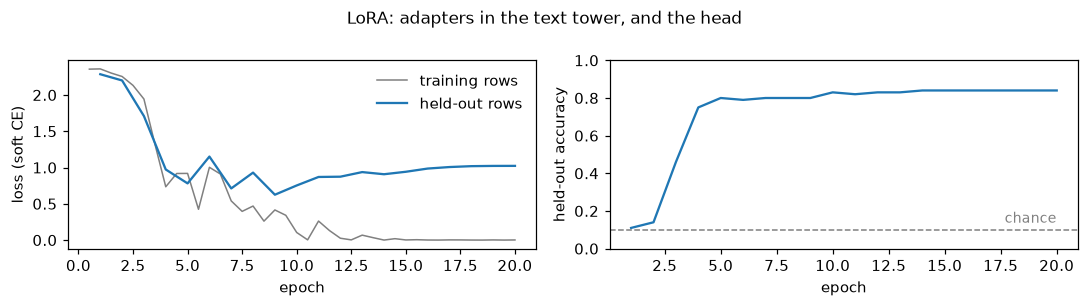

{'accuracy': 0.84,
 'soft_accuracy': 0.778,
 'brier': 0.223,
 'ece': 0.058,
 'n': 100}

In [ ]:
torch.manual_seed(0)
lora = quiet(decision_learner(data, ENC, train="lora", image_side=512))
print(lora)
t0 = time.time(); lora.fit_one_cycle(20, lr=1e-3)
print(f"trained in {time.time() - t0:.0f} s; temperatures {lora.temperatures}")
answers["LoRA"] = lora.decider().predict_batch([r["state"] for r in test], q)
plot_history(lora, "LoRA: adapters in the text tower, and the head", chance=0.1)
metrics(lora)

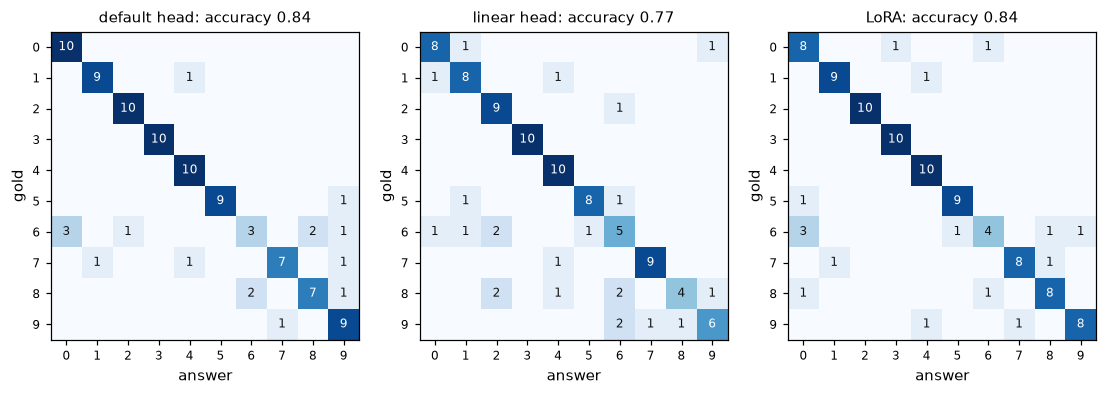

In [ ]:
del lora; release()
gold = [r["gold"]["digit"]["label"] for r in test]
plot_confusion({name: (gold, [a["digit"]["choice"] for a in ans]) for name, ans in answers.items()}, [str(d) for d in range(10)])

All three models get the 3s and 4s right, and nearly all the 2s. All three find the 6s hardest: the default head gets 3 of 10, LoRA 4 and the linear head 5, and the default head and LoRA send three of them to 0. LoRA's adapters, 811,008 weights in the text tower, reach the default head's 0.84 with better-calibrated probabilities: a Brier score of 0.223 against 0.262, and an ECE of 0.058 against 0.150. But they take six minutes to train, where the default head takes seven seconds on the cached anchors. LoRA's held-out loss is lowest at epoch 9 and climbs after it, while its accuracy holds at 0.84 from epoch 14 on.

## Hot dog, not hot dog: a noul

The photos and the split are the NeoMME tutorial's: [truepositive/hotdog_nothotdog](https://huggingface.co/datasets/truepositive/hotdog_nothotdog)'s train split, 40 photos of each class to train on and 40 others to score, drawn with the same seed.

In [ ]:
def hotdog_records(per_class=40, seed=0, src=None, dest=data_dir / "hotdog"):
    "Noul records over photos of hot dogs and of other food: `per_class` of each class to train on, `per_class` others to score"
    src = Path(src or snapshot_download("truepositive/hotdog_nothotdog", repo_type="dataset"))
    rng, q, train, test = random.Random(seed), {"hot_dog": {"type": "noul", "instructions": "The photo shows a hot dog."}}, [], []
    for cls, truth in (("hotdog", 1.0), ("not_hotdog", 0.0)):
        folder = next(p for p in sorted(src.rglob("*")) if p.is_dir() and p.parent.name == "train"
                      and p.name.replace("_", "") == cls.replace("_", ""))           # hotdog or hot_dog, not_hotdog or not_hot_dog
        files = sorted(folder.glob("*.jpg")); rng.shuffle(files)
        (dest / cls).mkdir(parents=True, exist_ok=True)
        for part, fs in ((train, files[:per_class]), (test, files[per_class:2 * per_class])):
            for f in fs:
                p = dest / cls / f.name
                if not p.exists(): shutil.copy2(f, p)                            # the copy keeps the file's time, which the cache keys on
                part.append({"id": f"{cls}-{f.stem}", "state": {"text": "", "image": str(p)}, "questions": q,
                             "gold": {"hot_dog": {"noul": truth}}})
    rng.shuffle(train); rng.shuffle(test)
    return train, test

htrain, htest = hotdog_records()
print(len(htrain), "cases to train on,", len(htest), "to score")
print(json.dumps(htrain[0], indent=1))

80 cases to train on, 80 to score
{
 "id": "hotdog-4518648",
 "state": {
  "text": "",
  "image": "modernvbert-images/hotdog/hotdog/4518648.jpg"
 },
 "questions": {
  "hot_dog": {
   "type": "noul",
   "instructions": "The photo shows a hot dog."
  }
 },
 "gold": {
  "hot_dog": {
   "noul": 1.0
  }
 }
}


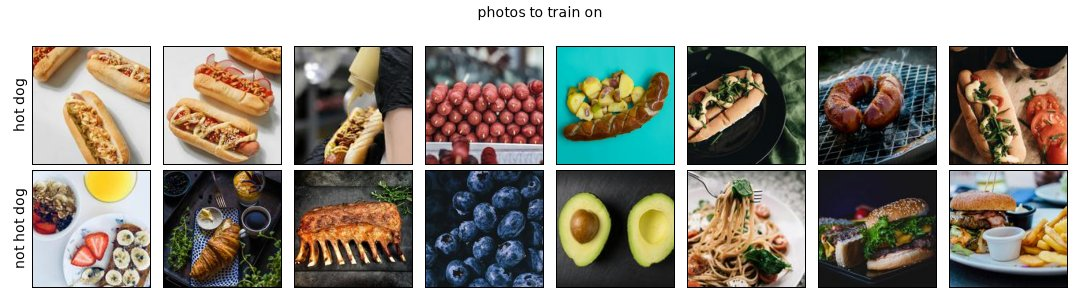

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(2, 8, figsize=(12, 3.4))
for row, (truth, name) in enumerate(((1.0, "hot dog"), (0.0, "not hot dog"))):
    for ax, r in zip(axs[row], [r for r in htrain if r["gold"]["hot_dog"]["noul"] == truth][:8]):
        ax.imshow(square(PILImage.open(r["state"]["image"]))); ax.set_xticks([]); ax.set_yticks([])
    axs[row, 0].set_ylabel(name, fontsize=11)
fig.suptitle("photos to train on", fontsize=11); plt.tight_layout(); show_figure(fig, "jpeg")

The photos are 224 pixels on their long side, and at `image_side=512` each becomes one square tile, enlarged a little over two times along its long side and more along its short one, since the processor rounds both sides up to whole tiles:

[CLS] noul question: The photo shows a hot dog. [SEP] [MASK] false: no, the statement does not hold [MASK] true: yes, the statement holds [SEP] <fake_token_around_image> <global-img> <image>×64 <fake_token_around_image> [SEP]
markers [13, 23] · qtype noul · 100 tokens



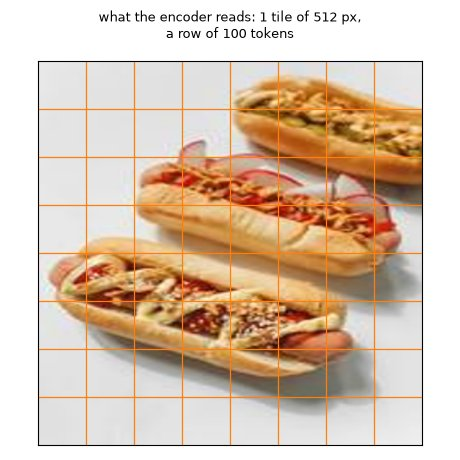

In [ ]:
hdata = TypedDecisions.from_records(htrain, valid=htest, calib=0.2)
torch.manual_seed(0)
hlearn = quiet(decision_learner(hdata, ENC, train="head", image_side=512))
hlearn.show_batch(1)
tiles, n = row_tiles(hlearn)
show_tiles(tiles, title=f"what the encoder reads: {len(tiles)} tile of 512 px,\na row of {n} tokens", fmt="jpeg")

The same three ways to train, with the same settings as for the digits. First the default head:

cached the anchors and trained in 20 s; temperatures {'noul': 0.5951, 'noul:2': 0.5951}


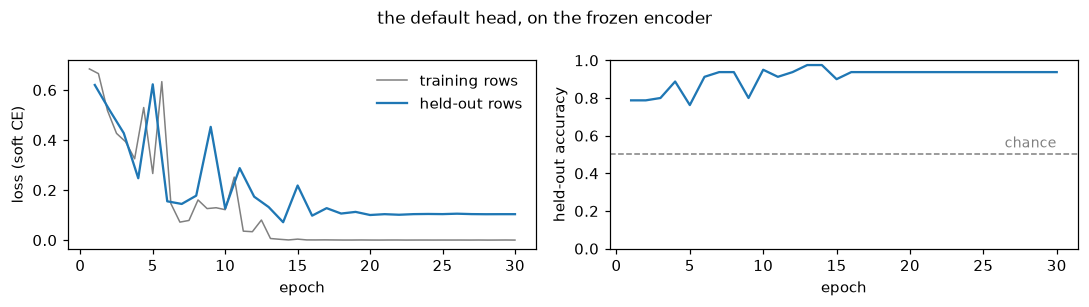

{'accuracy': 0.938,
 'soft_accuracy': 0.942,
 'brier': 0.088,
 'ece': 0.044,
 'n': 80}

In [ ]:
t0 = time.time()
hlearn.fit_one_cycle(30, lr=1e-3)
print(f"cached the anchors and trained in {time.time() - t0:.0f} s; temperatures {hlearn.temperatures}")
hq = htest[0]["questions"]
hanswers = {"default head": hlearn.decider().predict_batch([r["state"] for r in htest], hq)}
plot_history(hlearn, "the default head, on the frozen encoder", chance=0.5)
metrics(hlearn)

Then the linear head, and the probe on the image vectors:

In [ ]:
torch.manual_seed(0)
hlin = quiet(decision_learner(hdata, ENC, train="head", head="linear", image_side=512))
print(hlin.fit_linear())
hanswers["linear head"] = hlin.decider().predict_batch([r["state"] for r in htest], hq)
print(metrics(hlin))
(Xa, ya), (Xb, yb), (Xv, yv) = (image_vectors(hlin, s) for s in ("train", "calib", "valid"))
probes["hot dog"] = probe(torch.cat([Xa, Xb]), torch.cat([ya, yb]), Xv, yv)
print(f"the probe on ModernVBERT's image vectors: {probes['hot dog']:.2f}")
del hlearn, hlin; release()

{'train_loss': 0.004120664205402136, 'seconds': 0.24}
{'accuracy': 0.925, 'soft_accuracy': 0.878, 'brier': 0.117, 'ece': 0.051, 'n': 80}
the probe on ModernVBERT's image vectors: 0.98


And LoRA, 20 epochs at 10⁻³:

trained in 287 s; temperatures {'noul': 2.938, 'noul:2': 2.938}


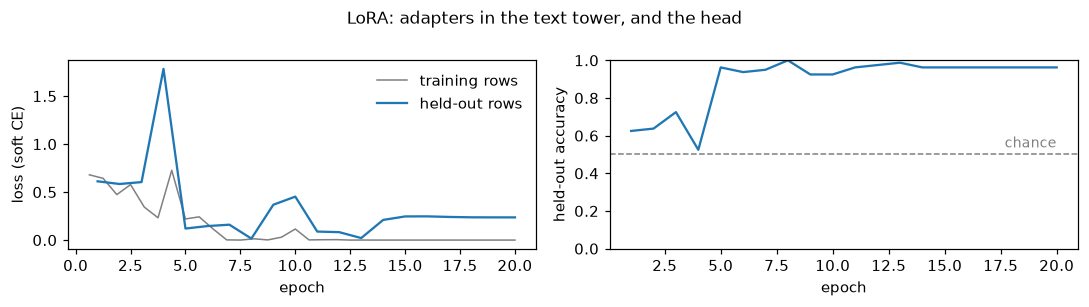

{'accuracy': 0.963,
 'soft_accuracy': 0.956,
 'brier': 0.059,
 'ece': 0.022,
 'n': 80}

In [ ]:
torch.manual_seed(0)
hlora = quiet(decision_learner(hdata, ENC, train="lora", image_side=512))
t0 = time.time(); hlora.fit_one_cycle(20, lr=1e-3)
print(f"trained in {time.time() - t0:.0f} s; temperatures {hlora.temperatures}")
hanswers["LoRA"] = hlora.decider().predict_batch([r["state"] for r in htest], hq)
plot_history(hlora, "LoRA: adapters in the text tower, and the head", chance=0.5)
metrics(hlora)

In [ ]:
del hlora; release()

### The answers

A noul's answer is the probability that the statement is true, shown on the cards as two bars. The default head on the first four test photos of each class:

{
 "hot_dog": {
  "type": "noul",
  "noul": 1.0,
  "confidence": 1.0,
  "answer_confidence": 1.0
 }
}


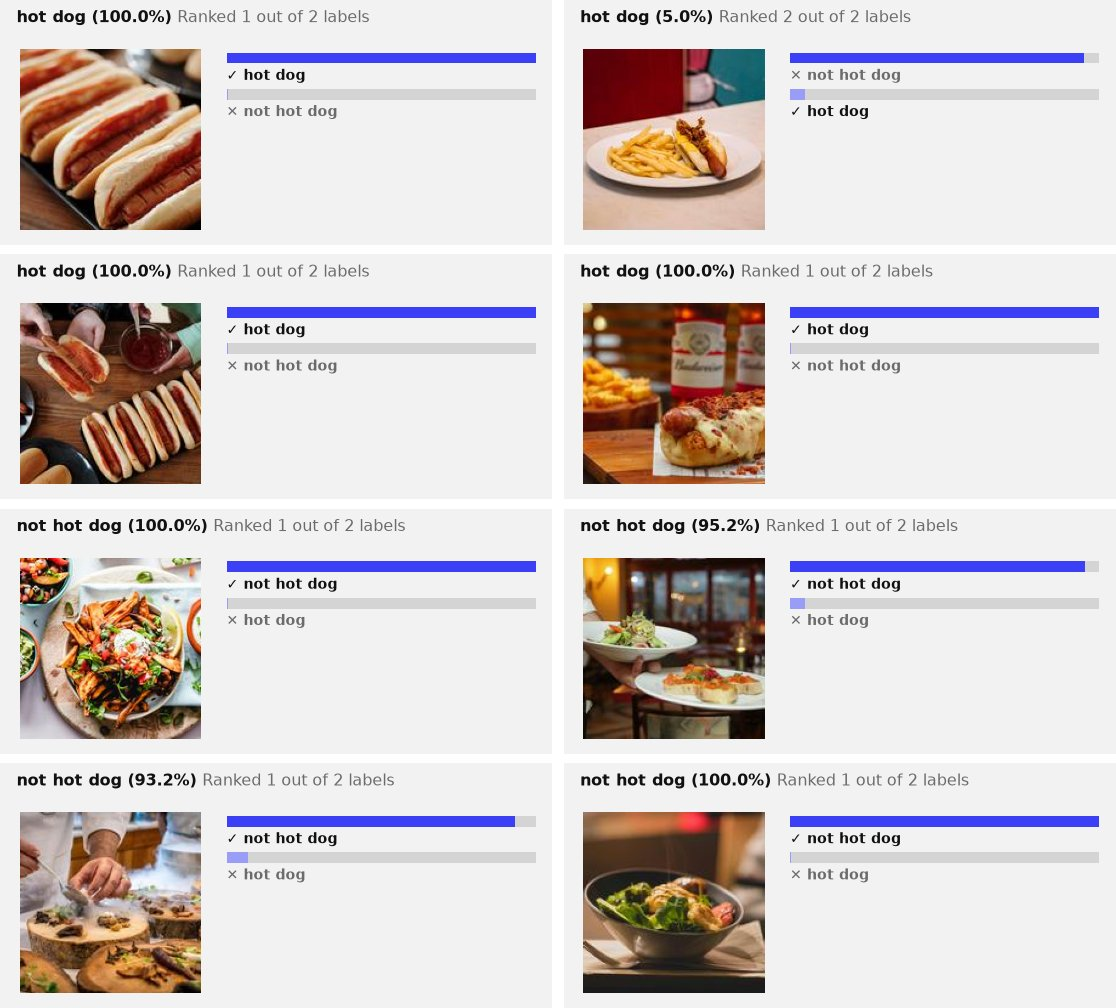

In [ ]:
print(json.dumps(hanswers["default head"][0], indent=1))
label = lambda truth: "hot dog" if truth else "not hot dog"
def hotdog_cards(answers, recs):
    "A card per record: its photo, its gold class, and the two classes' probabilities"
    return [{"image": r["state"]["image"], "gold": label(r["gold"]["hot_dog"]["noul"]),
             "probs": {"hot dog": a["hot_dog"]["noul"], "not hot dog": round(1 - a["hot_dog"]["noul"], 4)}} for a, r in zip(answers, recs)]

pick = [i for i, r in enumerate(htest) if r["gold"]["hot_dog"]["noul"] == 1][:4] + [i for i, r in enumerate(htest) if r["gold"]["hot_dog"]["noul"] == 0][:4]
show_cards(hotdog_cards([hanswers["default head"][i] for i in pick], [htest[i] for i in pick]), top=2, fmt="jpeg")

Across all 80 test photos, the probability each model gave *hot dog*, split by what the photo shows (right means on its class's side of the dashed line):

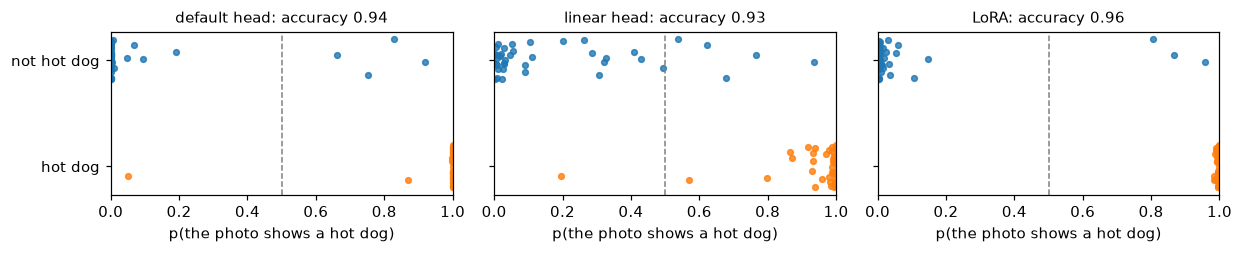

In [ ]:
#| code-fold: true
#| code-summary: figure code
truth = [r["gold"]["hot_dog"]["noul"] for r in htest]
fig, axs = plt.subplots(1, len(hanswers), figsize=(3.8 * len(hanswers), 2.4), sharey=True)
jitter = np.random.default_rng(0).uniform(-0.2, 0.2, len(htest))
for ax, (name, ans) in zip(axs, hanswers.items()):
    p = np.array([a["hot_dog"]["noul"] for a in ans])
    for k, (t, col) in enumerate(((1.0, "C1"), (0.0, "C0"))):
        sel = np.array(truth) == t
        ax.scatter(p[sel], k + jitter[sel], s=14, color=col, alpha=0.8)
    ax.axvline(0.5, color="gray", ls="--", lw=1)
    ax.set(xlim=(0, 1), yticks=[0, 1], xlabel="p(the photo shows a hot dog)"); ax.set_yticklabels(["hot dog", "not hot dog"])
    ax.set_title(f"{name}: accuracy {np.mean((p >= 0.5) == (np.array(truth) == 1)):.2f}", fontsize=10)
plt.tight_layout(); plt.show()

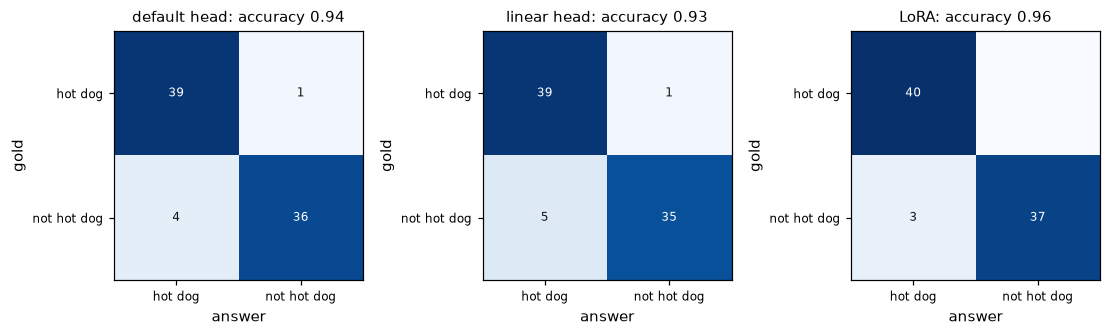

In [ ]:
plot_confusion({name: ([label(t) for t in truth], [label(a["hot_dog"]["noul"] >= 0.5) for a in ans]) for name, ans in hanswers.items()},
               ["hot dog", "not hot dog"])

Nearly every photo lands on the right side of 0.5, most of them at the edges. The default head gives 39 of the 40 hot dogs more than 0.8 and misses one, which it scores 0.05. Its four other mistakes are photos of other food called hot dogs, at 0.66 to 0.92. The temperature fitted on the 16 calib photos is 0.60, below 1: the head's probabilities were too cautious, and calibration sharpens them. NeoMME's temperatures on this task stopped at sysone's upper bound of 5, which flattens them as far as it can. LoRA misses no hot dog and calls three other photos hot dogs.

### Photos from the same shoot

The seeded split leaves some held-out photos with a sibling from the same shoot among the training photos, as the NeoMME tutorial found. The same check for ModernVBERT:

17 of the 40 held-out hot dogs, and 1 of the 40 other photos, have a training photo within 10 numbers of theirs


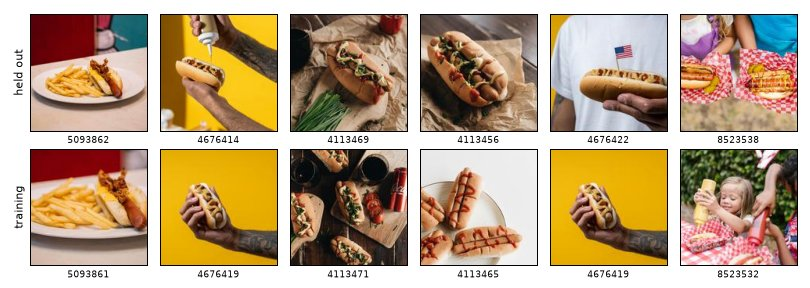

In [ ]:
num = lambda r: int(r["id"].split("-")[1])                       # the photo's file name, a number
sibling = np.array([min(abs(num(r) - num(s)) for s in htrain) <= 10 for r in htest])
hot = np.array(truth) == 1
print(f"{(sibling & hot).sum()} of the {hot.sum()} held-out hot dogs, and {(sibling & ~hot).sum()} of the {(~hot).sum()} other photos, "
      "have a training photo within 10 numbers of theirs")
pairs = [(r, min(htrain, key=lambda s: abs(num(r) - num(s)))) for r, s in zip(htest, sibling) if s][:6]
fig, axs = plt.subplots(2, len(pairs), figsize=(1.5 * len(pairs), 3.2), squeeze=False)
for k, (r, s) in enumerate(pairs):
    for row, x in enumerate((r, s)):
        axs[row, k].imshow(square(PILImage.open(x["state"]["image"]))); axs[row, k].set_xticks([]); axs[row, k].set_yticks([])
        axs[row, k].set_xlabel(x["id"].split("-")[1], fontsize=7)
axs[0, 0].set_ylabel("held out", fontsize=9); axs[1, 0].set_ylabel("training", fontsize=9)
plt.tight_layout(); show_figure(fig, "jpeg")

In [ ]:
right = {name: (np.array([a["hot_dog"]["noul"] for a in ans]) >= 0.5) == hot for name, ans in hanswers.items()}
pd.DataFrame({name: {f"hot dogs with a sibling in training ({(sibling & hot).sum()})": r[sibling & hot].mean(),
                     f"hot dogs without one ({(~sibling & hot).sum()})": r[~sibling & hot].mean(),
                     f"other photos ({(~hot).sum()})": r[~hot].mean()} for name, r in right.items()}).round(2)

,default head,linear head,LoRA
hot dogs with a sibling in training (17),0.94,0.94,1.00
hot dogs without one (23),1.00,1.00,1.00
other photos (40),0.90,0.88,0.92


The split is the NeoMME tutorial's, so the same 17 held-out hot dogs have a sibling in training. Unlike NeoMME, ModernVBERT gets all 23 hot dogs without a sibling right, with every model. The heads' one missed hot dog is one of those with a sibling. So the siblings don't flatter ModernVBERT here: its hot dogs are close to perfect either way, and its mistakes are other food it calls hot dog.

## Both tasks side by side

In [ ]:
def summary(answers, recs, qs):
    "Accuracy, Brier score and ECE of each model's answers"
    return pd.DataFrame({name: {k: v for k, v in answer_metrics([(qs, a, r["gold"]) for a, r in zip(ans, recs)]).items()
                                if k in ("accuracy", "brier", "ece")} for name, ans in answers.items()}).T

results = pd.concat({"digits": summary(answers, test, q), "hot dog": summary(hanswers, htest, hq)}).round(3)
results

accuracy  brier    ece
digits  default head     0.840  0.262  0.150
        linear head      0.770  0.307  0.097
        LoRA             0.840  0.223  0.058
hot dog default head     0.938  0.088  0.044
        linear head      0.925  0.117  0.051
        LoRA             0.962  0.059  0.022

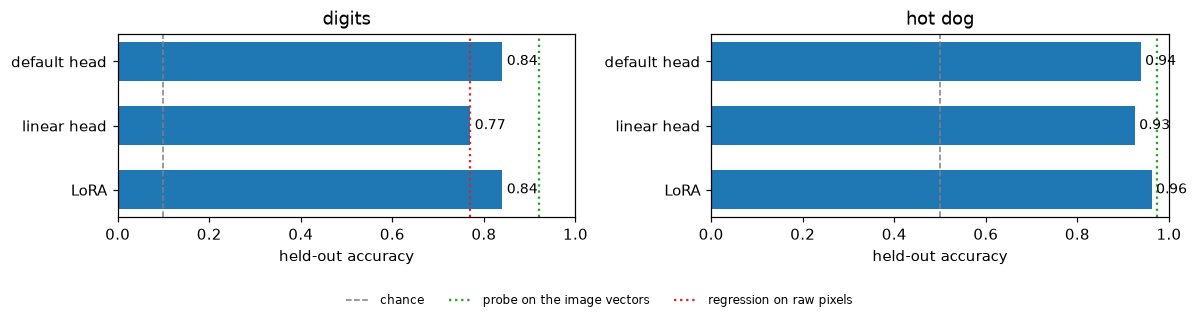

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(11, 2.9))
for ax, (task, chance) in zip(axs, (("digits", 0.1), ("hot dog", 0.5))):
    r = results.loc[task, "accuracy"][::-1]
    ax.barh(r.index, r.values, color="C0", height=0.6)
    for i, v in enumerate(r.values): ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
    ax.axvline(chance, color="gray", ls="--", lw=1, label="chance")
    ax.axvline(probes[task], color="C2", ls=":", lw=1.5, label="probe on the image vectors")
    if task == "digits": ax.axvline(pixel_probe, color="C3", ls=":", lw=1.5, label="regression on raw pixels")
    ax.set(xlim=(0, 1), title=task, xlabel="held-out accuracy")
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.1, 1, 1)); plt.show()

ModernVBERT is ahead of NeoMME in every row, on the same records and with the same recipes. On the digits it leads by 0.53 with the default head, 0.36 with the linear head and 0.51 with LoRA. On the photos it leads by 0.20, 0.23 and 0.24. On both tasks the default head on the frozen encoder comes within 0.03 of LoRA. It trains in seconds from the cached anchors, where LoRA takes five to six minutes. The probe on the image vectors, 0.92 and 0.98, sits above every model on the digits and just above them on the photos.

## One more setting: the image size

`image_side` sets how many tiles an image becomes: one up to 512 pixels, 2 × 2 and the global view at 1,024, and 3 × 3 and the global view at 1,536 (3 × 2 for a 3:2 photo). The tiles of an enlarged small image are zoomed-in crops of it, each 512 pixels to SigLIP.

a 149 × 224 photo at image_side=1024: 5 tiles of 512 × 512 pixels


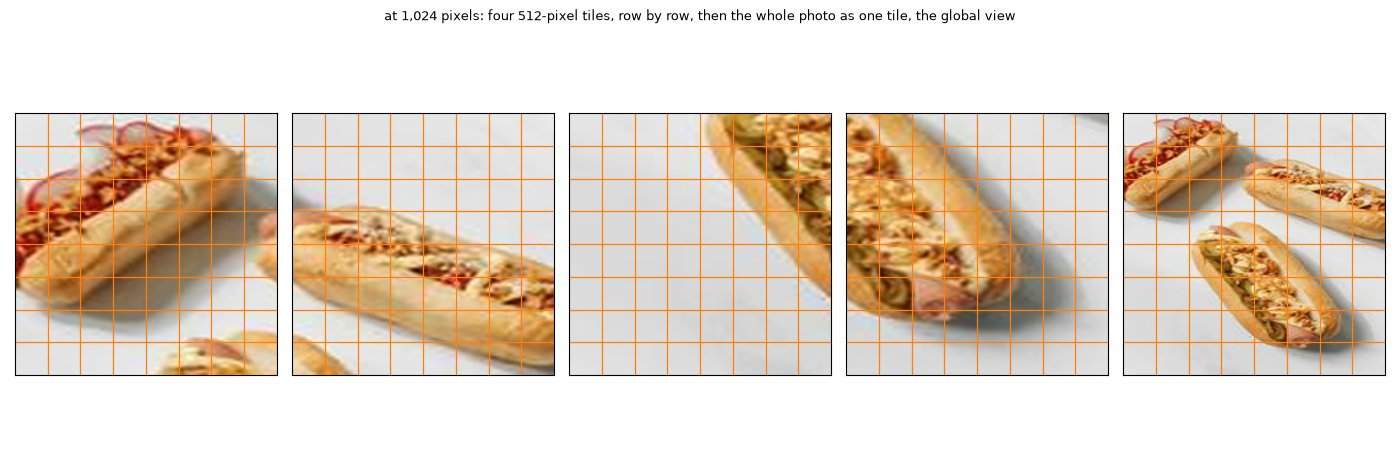

In [ ]:
from transformers import AutoProcessor
ip = AutoProcessor.from_pretrained(ENC).image_processor              # the processor alone: its settings, no weights
ip.size = {"longest_edge": 1024}
photo = PILImage.open(htrain[0]["state"]["image"]).convert("RGB")
px = torch.as_tensor(np.asarray(ip(images=[[photo]])["pixel_values"][0]))
std, mean = torch.tensor(ip.image_std)[:, None, None], torch.tensor(ip.image_mean)[:, None, None]
tiles = (px * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy()
print(f"a {photo.width} × {photo.height} photo at image_side=1024: {len(tiles)} tiles of {tiles.shape[1]} × {tiles.shape[2]} pixels")
show_tiles(tiles, title="at 1,024 pixels: four 512-pixel tiles, row by row, then the whole photo as one tile, the global view", fmt="jpeg")

The processor enlarged the 149 × 224 portrait to 1,024 pixels on its long side, then rounded both sides up to whole tiles, so the photo became a stretched square of 2 × 2 tiles. The fifth tile is the whole photo shrunk to 512 pixels, the global view that `<global-img>` marks in the rows above. At 512 pixels an image is a single tile, which is its own global view.

Both heads train in seconds from cached anchors, so the sweep is cheap, and the anchors are cached afresh for every size:

In [ ]:
sweep = {"digits": (train, test, (512, 1024, 1536)), "hot dog": (htrain, htest, (512, 1024, 1536))}
t0, sizes = time.time(), {}
for task, (tr, te, sides) in sweep.items():
    for side in sides:
        row = {}
        for head in ("linear", None):
            torch.manual_seed(0)
            l = quiet(decision_learner(TypedDecisions.from_records(tr, valid=te, calib=0.2), ENC, train="head", head=head, image_side=side))
            t1 = time.time()
            if head == "linear": l.fit_linear()
            else: l.fit_one_cycle(30, lr=1e-3)
            row["linear head" if head else "default head"] = round(l.validate()["accuracy"], 3)
            tiles, n = row_tiles(l)
            del l; release()
        sizes[(task, side)] = {"tiles (first row)": len(tiles), "tokens per row": n, **row}
sizes = pd.DataFrame(sizes).T.astype({"tiles (first row)": int, "tokens per row": int})
print(f"{2 * len(sizes)} learners in {time.time() - t0:.0f} s")
sizes

12 learners in 580 s


tiles (first row)  tokens per row  linear head  default head
digits  512                   1             102        0.770         0.840
        1024                  5             368        0.760         0.780
        1536                 10             699        0.790         0.750
hot dog 512                   1             100        0.925         0.938
        1024                  5             366        0.925         0.950
        1536                  7             499        0.938         0.912

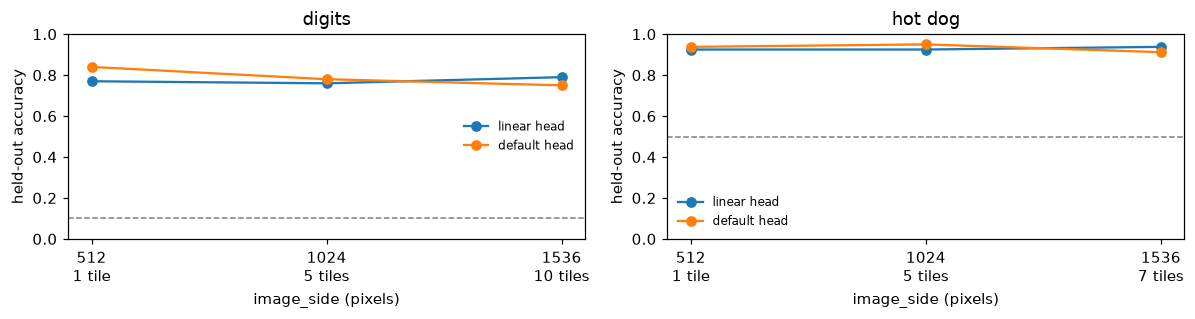

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
for ax, (task, chance) in zip(axs, (("digits", 0.1), ("hot dog", 0.5))):
    s = sizes.loc[task]
    for col, c in (("linear head", "C0"), ("default head", "C1")): ax.plot(s.index, s[col].astype(float), "o-", color=c, label=col, lw=1.5)
    ax.axhline(chance, color="gray", ls="--", lw=1)
    ax.set(ylim=(0, 1), xlabel="image_side (pixels)", ylabel="held-out accuracy", title=task)
    ax.set_xticks(list(s.index)); ax.set_xticklabels([f"{v}\n{t} tile{'s' if t > 1 else ''}" for v, t in zip(s.index, s["tiles (first row)"])])
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

More tiles don't help. On the digits the default head is best at one tile, falling from 0.84 at 512 pixels to 0.78 at 1,024 and 0.75 at 1,536, and the linear head stays between 0.76 and 0.79. On the photos every size lands between 0.91 and 0.95. A digit's tiles are zoomed-in pieces of blurred strokes, and a 224-pixel photo has no detail left to find at 1,536 pixels, while a row there costs five to seven times the tokens (499 and 699, against 100 and 102 at one tile). NeoMME's digits read best shrunk to 56 to 112 pixels. ModernVBERT sees every tile at SigLIP's 512 pixels, and for images this small the application's default of one tile is the right one. As in the NeoMME tutorial, these sizes were compared on the test split, which flatters the best of them. One more caveat: when this sweep ran, the application also shrank the default head's training batch for tiled images, from four rows to one at 1,024 and 1,536 pixels, although the head trains from cached anchors (a [finding](../23_modernvbert.ipynb#a-head-only-run), since fixed). So part of that head's drop at larger sizes may be the smaller batch. The linear head is fitted in one full batch, so it isn't affected, and it gains nothing from more tiles either.

## With Kaggle's photos

As in the NeoMME tutorial, the hot-dog task can run on Kaggle's [dansbecker/hot-dog-not-hot-dog](https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog), which needs a Kaggle account: log in to the Kaggle CLI, download the dataset, and point `hotdog_records` at its folder.

In [ ]:
#| eval: false
# kaggle datasets download dansbecker/hot-dog-not-hot-dog -p hot-dog-not-hot-dog --unzip
htrain, htest = hotdog_records(src="hot-dog-not-hot-dog", dest=data_dir / "hotdog-kaggle")

Everything after that runs as above.

In [ ]:
print(f"the whole notebook: {(time.time() - t_start) / 60:.1f} minutes")

the whole notebook: 23.2 minutes
